In [1]:
# Importerer nødvendige biblioteker
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier, plot_tree
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score, 
    accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay)


## Datarens!

In [2]:


# 1️. Les inn datasettet
# Her bruker vi relativ sti for å nå data-mappen fra src-mappen
df = pd.read_csv("../data/WA_Fn-UseC_-Telco-Customer-Churn.csv")

# 2️. Fjern mellomrom i kolonnenavn
# Noen ganger inneholder kolonnenavn ekstra mellomrom som kan skape problemer.
df.columns = [col.strip() for col in df.columns]


# 3️. Fjern mellomrom i tekstverdier (for eksempel " Yes " → "Yes")
for col in df.select_dtypes(include="object"):
    df[col] = df[col].str.strip()

# Prepare data for classification
df_churn = df.copy()

# 5️. Gjør om kolonnen "TotalCharges" til tall
# I rådataene er den ofte lagret som tekst. Vi tvinger den til tall.
# Hvis noen verdier ikke kan gjøres om, blir de NaN (manglende verdier) og de blir slettet i neste steg
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df = df.dropna(subset=['TotalCharges'])

# 7. # Konverterer kategoriske variabler til numeriske og lege det til i datasettet
df['gender_num'] = df['gender'].map({'Female': 0, 'Male': 1}).astype("float")
df['churn_num'] = df['Churn'].map({'No': 0, 'Yes': 1}).astype("float")

#    Contract -> antall måneder (variabelnavn som i koden din: ContractMonths)
df["ContractMonths"] = df["Contract"].map({
    "Month-to-month": 0,
    "One year": 12,
    "Two year": 24
}).astype("float")

#    SeniorCitizen: håndter både 0/1 (standard i datasettet) og "Yes/No"
if df["SeniorCitizen"].dtype == object:
    df["SeniorCitizen_num"] = df["SeniorCitizen"].map({"Yes": 1, "No": 0}).astype("float")
else:
    df["SeniorCitizen_num"] = pd.to_numeric(df["SeniorCitizen"], errors="coerce").astype("float")


# 7️. Se hvor mange manglende verdier som fortsatt finnes
print("Antall manglende verdier per kolonne:")
print(df.isna().sum())

# 8️. Lagre den rensede dataen til en ny fil i data-mappen
df.to_csv("../data/telco_clean.csv", index=False)
print("\n✅ Ferdig! Renset fil lagret som '../data/telco_clean.csv'")

# 9️. Vis de første radene for å sjekke resultatet
df.head()

Antall manglende verdier per kolonne:
customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges         0
Churn                0
gender_num           0
churn_num            0
ContractMonths       0
SeniorCitizen_num    0
dtype: int64

✅ Ferdig! Renset fil lagret som '../data/telco_clean.csv'


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,gender_num,churn_num,ContractMonths,SeniorCitizen_num
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,Month-to-month,Yes,Electronic check,29.85,29.85,No,0.0,0.0,0.0,0.0
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,One year,No,Mailed check,56.95,1889.50,No,1.0,0.0,12.0,0.0
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1.0,1.0,0.0,0.0
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,One year,No,Bank transfer (automatic),42.30,1840.75,No,1.0,0.0,12.0,0.0
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,0.0,1.0,0.0,0.0


## Oppgave 1

Vi ser om det er en sammenheng mellom hvor mye kundene betaler per måned og om de har sluttet å bruke tjenesten.


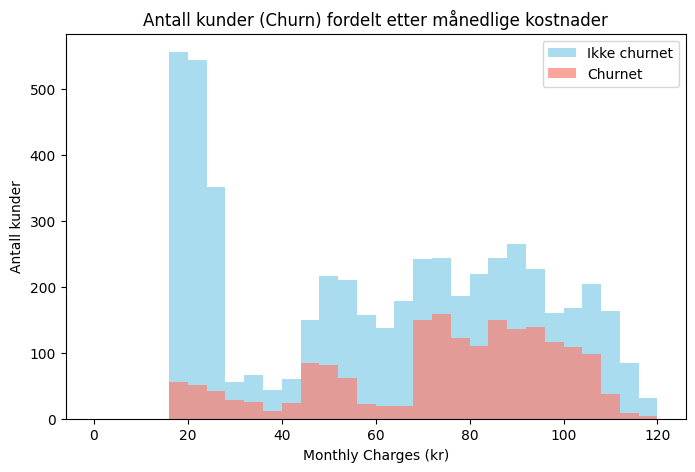

In [3]:


# 1️. Les inn datasettet
df = pd.read_csv('../data/telco_clean.csv')

# 2️. Fjern rader uten verdier for MonthlyCharges eller Churn
df = df[df["MonthlyCharges"].notnull()]
df = df[df["Churn"].notnull()]

# 3️. Lag to separate lister: en for kunder som har churnet og en for de som ikke har
churn_yes = df[df["Churn"] == "Yes"]["MonthlyCharges"]
churn_no  = df[df["Churn"] == "No"]["MonthlyCharges"]

# 4️. Lag et histogram som viser fordelingen av MonthlyCharges for begge grupper
plt.figure(figsize=(8,5))
plt.hist(churn_no, bins=30, range=(0, 120), alpha=0.7, label="Ikke churnet", color="skyblue")
plt.hist(churn_yes, bins=30, range=(0, 120), alpha=0.7, label="Churnet", color="salmon")

# 5️. Legg til tittel og aksetekster
plt.title("Antall kunder (Churn) fordelt etter månedlige kostnader")
plt.xlabel("Monthly Charges (kr)")
plt.ylabel("Antall kunder")
plt.legend()
plt.show()



Diagrammet viser at kunder med lavere månedlige kostnader sjeldnere slutter, mens de som betaler mer per måned oftere slutter(churner).
Dette kan tyde på at prisnivået påvirker kundelojalitet, dyrere tjenester gir større risiko for at kunden sier opp. Vi ser det er en økning fra 60 og oppover hvor det er mange flere som slutter.

## oppgave 2



In [5]:
# 1) Les renset data 
df = pd.read_csv("../data/telco_clean.csv")

# 2) Velg features og target
features = ["tenure", "TotalCharges", "SeniorCitizen_num", "ContractMonths", "gender_num"]
target = "MonthlyCharges"

# 3) Klargjør data (dropp rader med mangler i relevante felt)
data = df[features + [target]].dropna()

X = data[features].values
y = data[target].values

# 4) Del data i trenings- og testsett
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 5) Tren lineær regresjon
model = LinearRegression()
model.fit(X_train, y_train)

# 6) Prediksjon og evaluering
y_pred   = model.predict(X_test)
r2_lin   = r2_score(y_test, y_pred)
mse_lin  = mean_squared_error(y_test, y_pred)
rmse_lin = np.sqrt(mse_lin)
mae_lin  = mean_absolute_error(y_test, y_pred)

# 7) Rapporter
coef_table = pd.DataFrame({
    "feature": features,
    "coefficient": model.coef_
}).sort_values("feature").round(4)

print(f"Intercept: {model.intercept_:.4f}")
print("\nKoeffisienter:")
print(coef_table.to_string(index=False))
print(f"\nR² (forklart varians): {r2_lin:.4f}")
print(f"RMSE (samme enhet som MonthlyCharges): {rmse_lin:.4f}")
print(f"MAE: {mae_lin:.4f}")

# 8) Eksempelprediksjoner
preview = pd.DataFrame({"y_true": y_test[:10], "y_pred": y_pred[:10]}).round(2)
print("\nEksempel på prediksjoner (første 10):")
print(preview.to_string(index=False))


Intercept: 57.3342

Koeffisienter:
          feature  coefficient
   ContractMonths      -0.4877
SeniorCitizen_num       5.9408
     TotalCharges       0.0177
       gender_num      -0.7421
           tenure      -0.9094

R² (forklart varians): 0.7183
RMSE (samme enhet som MonthlyCharges): 15.7783
MAE: 12.3931

Eksempel på prediksjoner (første 10):
 y_true  y_pred
  25.00   21.91
  24.70   48.29
 102.25   68.80
  55.05   58.85
  29.45   54.73
  29.80   55.53
  80.85   81.53
  91.50   74.39
  69.50   65.52
  85.25   82.80


## Oppgave 3



Ytelse regresjonstre (max_depth=6):
R²-score: 0.85
Mean Absolute Error (MAE): 7.66
Mean Squared Error (MSE): 130.1
Root Mean Squared Error (RMSE): 11.41


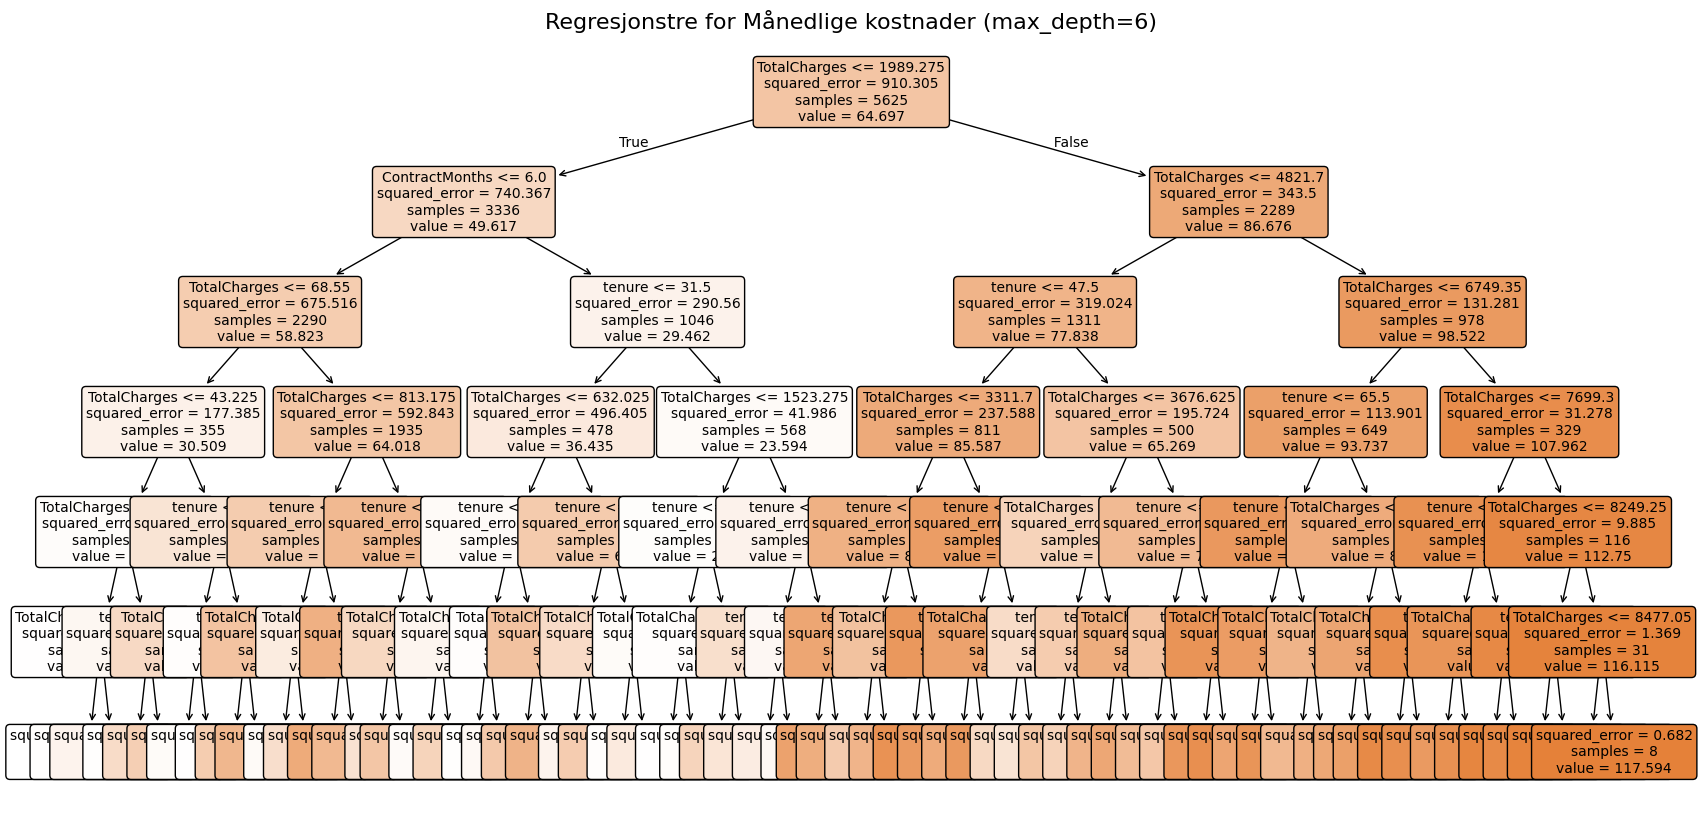


Sammenligning av regresjonstrær med ulike dybder:


,Dybde,MAE,MSE,RMSE,R²
0,3,13.94,322.44,17.96,0.64
1,6,7.66,130.10,11.41,0.85
2,7,5.50,71.19,8.44,0.92
3,12,2.49,15.18,3.90,0.98


In [ ]:
# Regresjonstre med max_depth=6 (X_train og y_train fra oppgave 2 brukes)
tree_model = DecisionTreeRegressor(max_depth=6, random_state=42)
tree_model.fit(X_train, y_train)
y_tree_pred = tree_model.predict(X_test)

# Evaluering av regresjontreet
r2_tree = r2_score(y_test, y_tree_pred)
mae_tree = mean_absolute_error(y_test, y_tree_pred)
mse_tree = mean_squared_error(y_test, y_tree_pred)
rmse_tree = np.sqrt(mse_tree)

# Skriver ut resultatene for regresjontreet
print(f'\nYtelse regresjonstre (max_depth=6):')
print(f'R²-score: {round(r2_tree, 2)}')
print(f'Mean Absolute Error (MAE): {round(mae_tree, 2)}')
print(f'Mean Squared Error (MSE): {round(mse_tree, 2)}')
print(f'Root Mean Squared Error (RMSE): {round(rmse_tree, 2)}')

# Plotter regresjontreet
plt.figure(figsize=(20,10))
plot_tree(tree_model, feature_names=features, filled=True, rounded=True, fontsize=10)
plt.title('Regresjonstre for Månedlige kostnader (max_depth=6)', fontsize=16)
plt.show()

#Evaluerer med forskjellige dybder for å sammenligne
depths = [3, 6, 7, 12]
results = []

for depth in depths:
    reg_tree = DecisionTreeRegressor(max_depth=depth, random_state=42)
    reg_tree.fit(X_train, y_train)
    y_pred = reg_tree.predict(X_test)
    
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    results.append([depth, mae, mse, rmse, r2])

# Lager en DataFrame fra resultatene
results_df = pd.DataFrame(results, columns=['Dybde', 'MAE', 'MSE', 'RMSE', 'R²'])
results_df = results_df.round(2)  

print("\nSammenligning av regresjonstrær med ulike dybder:")
display(results_df)

Et regresjonstre med maksimal dybde på 7 viser seg å være mest hensiktsmessig for denne modellen. Det gir høy forklaringskraft (R² = 0.91) og relativt lav feil (RMSE = 9.11) uten tegn til overfitting. En videre økning til dybde 12 gir riktignok høyere R² (0.98), men dette skyldes trolig overtilpasning til treningsdataene. Dybde 7 fanger dermed opp de viktigste mønstrene i dataene og gir en god balanse mellom nøyaktighet og generalisering. De mest betydningsfulle variablene er kontraktlengde, totale kostnader og kundens varighet.



## Oppgave 4

In [ ]:
# Modell-sammenligning: LinearRegression vs DecisionTree (depth=7)
# sammenligner MAE, MSE, RMSE og R².

# 1. Tren Decision Tree (depth=7)
tree_model = DecisionTreeRegressor(max_depth=7, random_state=42)
tree_model.fit(X_train, y_train)
y_pred_tree = tree_model.predict(X_test)

mae_tree_7 = mean_absolute_error(y_test, y_pred_tree)
mse_tree_7 = mean_squared_error(y_test, y_pred_tree)
rmse_tree_7 = np.sqrt(mse_tree_7)
r2_tree_7 = r2_score(y_test, y_pred_tree)


# 2. Lag en sammenlignings-tabell
compare_df = pd.DataFrame([
    ["LinearRegression", round(mae_lin, 2), round(mse_lin, 2), round(rmse_lin, 2), round(r2_lin, 2)],
    ["DecisionTree(depth=7)", round(mae_tree_7, 2), round(mse_tree_7, 2), round(rmse_tree_7, 2), round(r2_tree_7, 2)]
], columns=["Model", "MAE", "MSE", "RMSE", "R²"]) 

print("Modell-sammenligning (lavere MAE/RMSE/MSE er bedre; høyere R² er bedre):")
from IPython.display import display
compare_df = compare_df.round(4)
display(compare_df)

# 3. Kort tolkning
if rmse_lin < rmse_tree:
    better_rmse = "LinearRegression"
else:
    better_rmse = "DecisionTree(depth=7)"
if r2_lin > r2_tree:
    better_r2 = "LinearRegression"
else:
    better_r2 = "DecisionTree(depth=7)"

print(f"\nKort oppsummering: Lavest RMSE: {better_rmse}; Høyest R²: {better_r2}.")


Modell-sammenligning (lavere MAE/RMSE/MSE er bedre; høyere R² er bedre):


,Model,MAE,MSE,RMSE,R²
0,LinearRegression,12.39,248.96,15.78,0.72
1,DecisionTree(depth=7),5.50,71.19,11.41,0.92



Kort oppsummering: Lavest RMSE: DecisionTree(depth=7); Høyest R²: DecisionTree(depth=7).


## Oppgave 5

In [6]:

# 1) Les data FRA CSV (ikke fra df fra tidligere celler!)
df = pd.read_csv("../data/telco_clean.csv")

# 3) Lag X og y (bruk kolonnene som finnes i CSV)
features = ["tenure", "TotalCharges", "MonthlyCharges", "ContractMonths", "gender_num"]
target = "churn_num"

# 4) Klargjør data (dropp rader med mangler i relevante felt)
data = df[features + [target]].dropna()

X = data[features].values
y = data[target].values

# Split data
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X, y, test_size=0.2, random_state=42)

# Test depths 3 to 8
depths = range(3, 9)
results = []

for depth in depths:
    clf = DecisionTreeClassifier(max_depth=depth, random_state=42)
    clf.fit(X_train_c, y_train_c)
    y_pred = clf.predict(X_test_c)

    results.append({
        'Depth': depth,
        'Accuracy': accuracy_score(y_test_c, y_pred),
        'Precision': precision_score(y_test_c, y_pred),
        'Recall': recall_score(y_test_c, y_pred),
        'F1-Score': f1_score(y_test_c, y_pred)
    })

# Display results
results_df = pd.DataFrame(results)
print("Decision Tree Performance by Depth:")
print(results_df.to_string(index=False))

# Find best depth based on F1-Score
best_depth = results_df.loc[results_df['F1-Score'].idxmax(), 'Depth']
print(f"\nBest depth: {int(best_depth)} (highest F1-Score)")


Decision Tree Performance by Depth:
 Depth  Accuracy  Precision   Recall  F1-Score
     3  0.781805   0.655814 0.377005  0.478778
     4  0.784648   0.620339 0.489305  0.547085
     5  0.778252   0.592262 0.532086  0.560563
     6  0.772566   0.612500 0.393048  0.478827
     7  0.778962   0.601286 0.500000  0.545985
     8  0.767591   0.586081 0.427807  0.494590

Best depth: 5 (highest F1-Score)


## Oppgave 6